In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("myexcel.csv") 
print(df.head())

            Name            Team  Number Position  Age      Height  Weight  \
0  Avery Bradley  Boston Celtics       0       PG   25  02/06/2023     180   
1    Jae Crowder  Boston Celtics      99       SF   25  06/06/2023     235   
2   John Holland  Boston Celtics      30       SG   27  05/06/2023     205   
3    R.J. Hunter  Boston Celtics      28       SG   22  05/06/2023     185   
4  Jonas Jerebko  Boston Celtics       8       PF   29  10/06/2023     231   

             College     Salary  
0              Texas  7730337.0  
1          Marquette  6796117.0  
2  Boston University        NaN  
3      Georgia State  1148640.0  
4                NaN  5000000.0  


In [3]:
df['Height'] = np.random.randint(150, 181, size=len(df))

In [4]:
print("Missing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values:
 Name         0
Team         0
Number       0
Position     0
Age          0
Height       0
Weight       0
College     84
Salary      11
dtype: int64
Duplicate rows: 0


In [5]:
df.drop_duplicates(inplace=True)


Employee distribution by team:
 Team
New Orleans Pelicans      4.148472
Memphis Grizzlies         3.930131
Utah Jazz                 3.493450
Milwaukee Bucks           3.493450
New York Knicks           3.493450
Boston Celtics            3.275109
Los Angeles Clippers      3.275109
Los Angeles Lakers        3.275109
Phoenix Suns              3.275109
Sacramento Kings          3.275109
Brooklyn Nets             3.275109
Philadelphia 76ers        3.275109
Toronto Raptors           3.275109
Golden State Warriors     3.275109
Indiana Pacers            3.275109
Detroit Pistons           3.275109
Cleveland Cavaliers       3.275109
Chicago Bulls             3.275109
Houston Rockets           3.275109
San Antonio Spurs         3.275109
Atlanta Hawks             3.275109
Dallas Mavericks          3.275109
Charlotte Hornets         3.275109
Miami Heat                3.275109
Denver Nuggets            3.275109
Washington Wizards        3.275109
Portland Trail Blazers    3.275109
Oklahoma City Thu

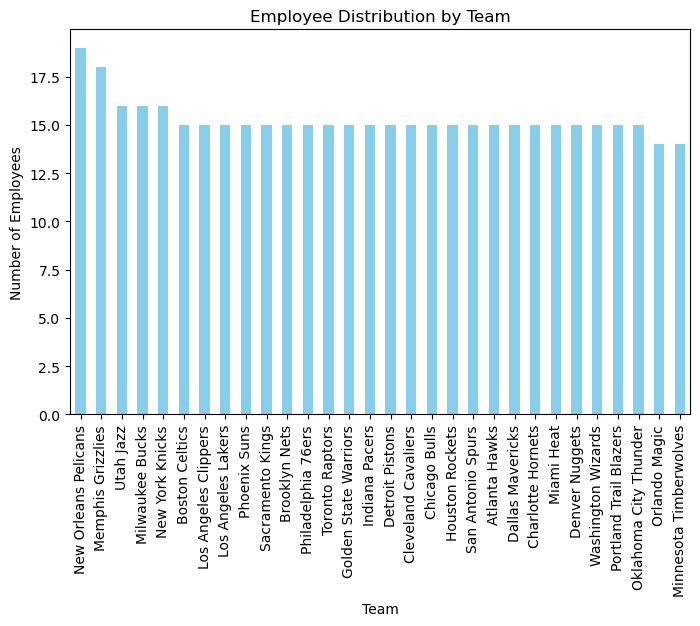

In [6]:
team_dist = df['Team'].value_counts()
team_percent = (team_dist / len(df)) * 100
print("\nEmployee distribution by team:\n", team_percent)

plt.figure(figsize=(8,5))
team_dist.plot(kind='bar', color='skyblue')
plt.title('Employee Distribution by Team')
plt.xlabel('Team')
plt.ylabel('Number of Employees')
plt.show()


Employee distribution by position:
 Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64


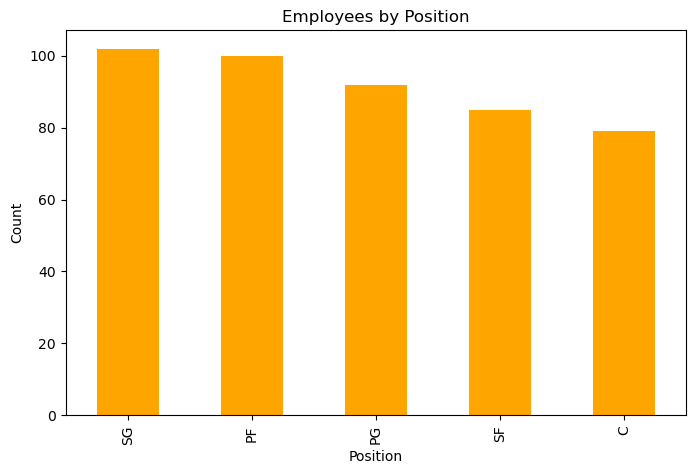

In [7]:
position_dist = df['Position'].value_counts()
print("\nEmployee distribution by position:\n", position_dist)

plt.figure(figsize=(8,5))
position_dist.plot(kind='bar', color='orange')
plt.title('Employees by Position')
plt.xlabel('Position')
plt.ylabel('Count')
plt.show()


Age group distribution:
 AgeGroup
20-29    346
30-39     91
40-49      0
50-59      0
Name: count, dtype: int64


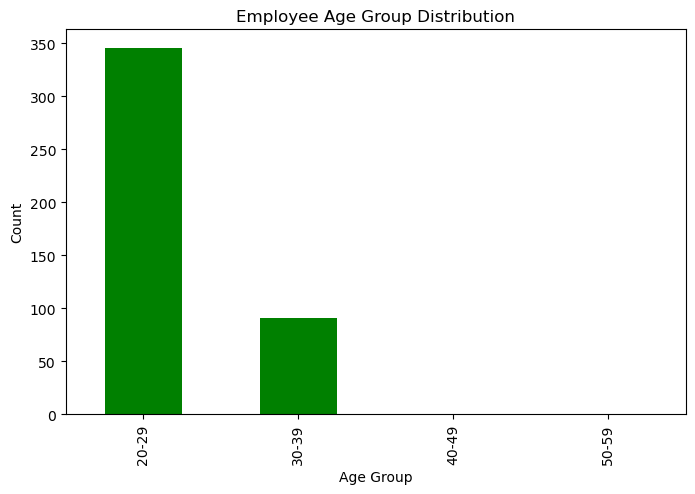

Predominant age group: 20-29


In [8]:
bins = [20, 30, 40, 50, 60]
labels = ['20-29', '30-39', '40-49', '50-59']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_group_dist = df['AgeGroup'].value_counts().sort_index()
print("\nAge group distribution:\n", age_group_dist)

plt.figure(figsize=(8,5))
age_group_dist.plot(kind='bar', color='green')
plt.title('Employee Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

print("Predominant age group:", age_group_dist.idxmax())



Team with highest salary expenditure: Cleveland Cavaliers
Position with highest salary expenditure: C


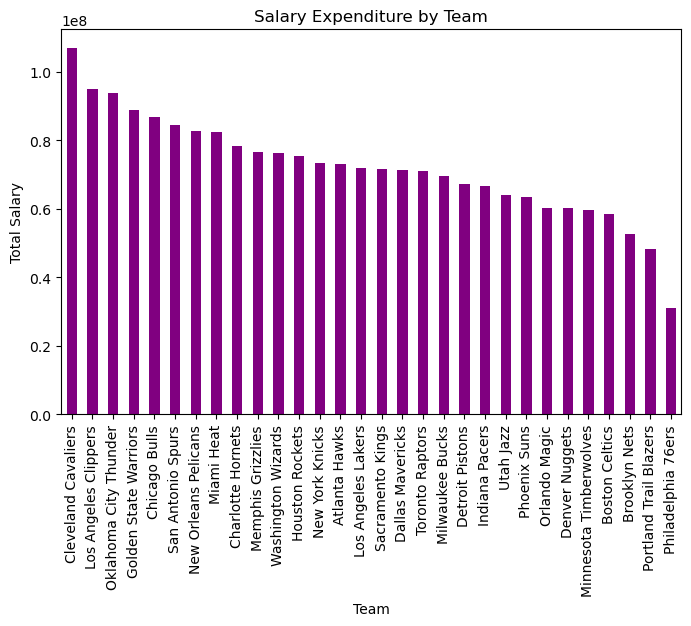

In [9]:
team_salary = df.groupby('Team')['Salary'].sum().sort_values(ascending=False)
position_salary = df.groupby('Position')['Salary'].sum().sort_values(ascending=False)

print("\nTeam with highest salary expenditure:", team_salary.idxmax())
print("Position with highest salary expenditure:", position_salary.idxmax())

plt.figure(figsize=(8,5))
team_salary.plot(kind='bar', color='purple')
plt.title('Salary Expenditure by Team')
plt.xlabel('Team')
plt.ylabel('Total Salary')
plt.show()



Correlation between Age and Salary: 0.21


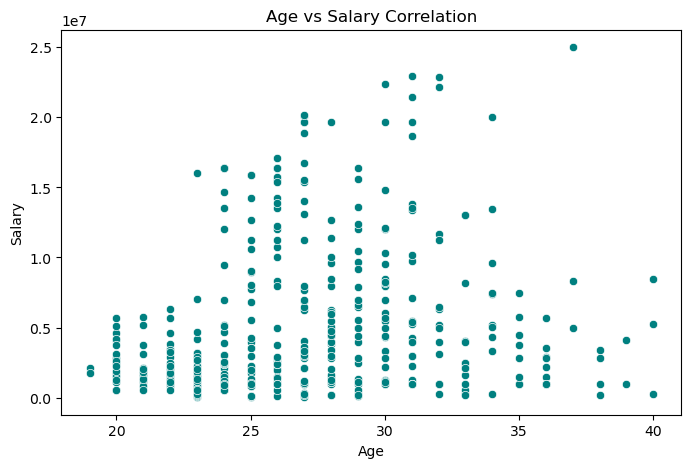

In [10]:
corr = df['Age'].corr(df['Salary'])
print("\nCorrelation between Age and Salary:", round(corr, 2))

plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Salary', data=df, color='teal')
plt.title('Age vs Salary Correlation')
plt.show()

In [11]:
print("\n--- DATA INSIGHTS ---")
print(f"1. Most employees are in the '{team_dist.idxmax()}' team.")
print(f"2. Common position: {position_dist.idxmax()}.")
print(f"3. Predominant age group: {age_group_dist.idxmax()}.")
print(f"4. Highest salary expenditure team: {team_salary.idxmax()}.")
print(f"5. Correlation between Age and Salary: {round(corr, 2)}.")
print("\nProject completed successfully ✅")


--- DATA INSIGHTS ---
1. Most employees are in the 'New Orleans Pelicans' team.
2. Common position: SG.
3. Predominant age group: 20-29.
4. Highest salary expenditure team: Cleveland Cavaliers.
5. Correlation between Age and Salary: 0.21.

Project completed successfully ✅
